# Species distribution modeling with multimodal satellite and environmental data

Welcome to this wonderfull main to discover the beauty of mother earth, enjoy your work and be happy :)

## 1. Setup

In [1]:
%pip install -r requirements.txt

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.8 MB 2.0 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.8 MB 1.7 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/12.8 MB 1.5 MB/s eta 0:00:08
   ---- ----------------------------------- 1.6/12.8 MB 1.5 MB/s eta 0:00:08
   ----- ---------------------------------- 1.8/12.8 MB 1.5 MB/s eta 0:00:08
   ------ --------------------------------- 2.1/12.8 MB 1.4 MB/s eta 0:00:08
   ------- -------------------------------- 2.4/12.8 MB 1.3 MB/s eta 0:00:08
   -------- ------------------------------- 2.6/12.8 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 2.9/12.8 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 3.1/12.8 MB 1.3 MB/s eta 0:00:08
   ---------- ----------------------------- 3.4/12.8 MB 1.3 MB/s eta 0:00:08
   ----------

In [1]:
import torch
import torch.nn as nn
import satlaspretrain_models 
from satlaspretrain_models import Model
from torch.utils.data import dataset
from torch.utils.data import DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
from pathlib import Path
try:
    root = Path(__file__).resolve().parent
except NameError:
    root = Path.cwd()  # fallback for Jupyter notebooks

while root.parent != root:
    if any((root / marker).exists() for marker in ["README.md"]):
        break
    root = root.parent

# Fallback in case nothing found
if not any((root / marker).exists() for marker in ["README.md"]):
    print("Could not locate project root — defaulting to current working directory")
    root = Path.cwd()

root = str(root)
print(f"Root folder detected at: {root}")

Root folder detected at: c:\Users\moeag\Documents\TRAVAIL\EPFL\S3\5_Image processing for earth observation\projet\IPEO-Species-distribution


## 2. Data loading

In [3]:
from Aurelien_DataLoader.GeoPlantDataset import GeoPlantDataset, viz_sample
train=GeoPlantDataset(data_folder=f"{root}/data", split='train')

def load_dataloader(batch_size, split='train'):
  return DataLoader(
      GeoPlantDataset(data_folder=f"{root}/data", split=split),
      batch_size=batch_size,
      shuffle=(split=='train'),       # we shuffle the image order for the training dataset
      num_workers=2                   # perform data loading with two CPU threads
  )

## 3. Create model

In [ ]:
# charge weight pretrained : 
#weights_manager = satlaspretrain_models.Weights()
#sat_model = weights_manager.get_pretrained_model("Sentinel2_SwinB_SI_RGB", fpn=True, head=satlaspretrain_models.Head.CLASSIFY, 
#                                                num_categories=10, device='cpu')
# sat_model = Model(backbone="Sentinel2_SwinB_SI_RGB")

In [4]:
# neural network with 3 NN (for each modality) and a classifier at the end #same architecture as ex7 and ex9
#maybe add one layer in the CNN for time series?

class multimodal_SDM (nn.Module): #heritates from class nn.Module
    
    def __init__(self, dim_NN_env=128, dim_NN_sat=4096, dim_NN_timeseries=64): #dimension of output of neural networks
        super(multimodal_SDM, self).__init__()  #call the init of the parent class
        
        self.dim_NN_env=dim_NN_env

        self.dim_NN_sat=dim_NN_sat

        self.dim_NN_timeseries=dim_NN_timeseries
        
        self.MLP_env = nn.Sequential( #19 bioclim variables to 128 values
            nn.Linear(19,50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 128),
            nn.ReLU()
            )
        
        self.CNN_sat= nn.Sequential(
            #Alexnet ex7 with 5 hidden convolution layers + a linear layer at the end
            #input: 3 channels, 128*128 pixels
            
            nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.AdaptiveAvgPool2d((6, 6)),
            nn.Flatten(), 
            nn.Linear(256*6*6, dim_NN_sat), #i don't know if this is really the good dimension as input
            nn.ReLU()
        )
        )


        #Model(backbone="Sentinel2_SwinB_SI_RGB", pretrained=True)


        self.CNN_timeseries= nn.Sequential(
            #R G B NIR with 10 years and 4 seasons= 40 values: 4 channels, length 40
            #Like Alexnet but shorter (2 convolutionnal layers) and in 1D
            nn.Conv1d(in_channels=4, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Flatten(), #before linear, otherwise error
            nn.Linear(32*10, dim_NN_timeseries), # 32 channels * length 10 (2 poolings of size 2 equivalent to divide /4 the length of the input) ?
            nn.ReLU()
        )

        self.classifier= nn.Sequential(
            nn.Linear(dim_NN_env+dim_NN_sat+dim_NN_timeseries, 1000),
            nn.ReLU(),
            nn.Linear(1000, 342),
            nn.Sigmoid()
        )

    def forward (self,x):
        '''x is a GeoPlantDataset object containing the 3 modalities:
        - env_variables
        - satellite_patches
        - landsat_timeseries
        '''
        env_variables=x["env_variables"].float()
        satellite_patches=x["satellite_patch"].float()
        landsat_timeseries=x["landsat_timeseries"].float()

        #pass each modality through its NN
        NN_env_out=self.MLP_env(env_variables)
        NN_sat_out=self.CNN_sat(satellite_patches)
        NN_time_series_out=self.CNN_timeseries(landsat_timeseries)

        #concatenate the outputs
        combined=torch.cat((NN_env_out, NN_sat_out, NN_time_series_out), dim=1)

        #pass through the classifier
        output=self.classifier(combined)
        return output

In [50]:
#train.satellite_patches


dict_keys(['survey_id', 'lon', 'lat', 'env_variables', 'landsat_timeseries', 'satellite_patch', 'species_labels'])

In [5]:
#let's test it
dataloader_train = load_dataloader(batch_size=8, split='train')
data = iter(dataloader_train).__next__()
model = multimodal_SDM() #load the model
pred = model(data) #perform 1 forward pass

# assert pred.size(1) == len(train.LABEL_CLASSES), f'ERROR: invalid number of model output channels (should be # classes {len(dataset_train.LABEL_CLASSES)}, got {pred.size(1)})'
# assert pred.size(2) == data.size(2), f'ERROR: invalid spatial height of model output (should be {data.size(2)}, got {pred.size(2)})'
# assert pred.size(3) == data.size(3), f'ERROR: invalid spatial width of model output (should be {data.size(3)}, got {pred.size(3)})'

In [7]:
pred.shape

torch.Size([8, 342])

In [8]:
target=data['species_labels']

c:\Users\moeag\anaconda3\envs\ipeo_env\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\moeag\anaconda3\envs\ipeo_env\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\moeag\anaconda3\envs\ipeo_env\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\moeag\anaconda3\envs\ipeo_env\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\moeag\anaconda3\envs\ipeo_env\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be mean

[nan, nan, nan, 0.5714285714285714, nan, 1.0, 0.25, nan, 0.8571428571428572, nan, nan, nan, nan, nan, nan, 0.8, nan, nan, 0.16666666666666663, nan, nan, nan, nan, nan, 0.33333333333333337, 1.0, nan, nan, 0.25, 0.2857142857142857, nan, nan, nan, 0.2857142857142857, nan, 0.8571428571428572, nan, nan, nan, 0.4285714285714286, nan, 0.2857142857142857, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.2857142857142857, nan, nan, 0.0, nan, nan, nan, 0.2857142857142857, nan, nan, 1.0, 0.4285714285714286, nan, 0.6666666666666666, nan, nan, 0.4285714285714286, nan, nan, nan, nan, 0.1428571428571429, nan, 0.8571428571428572, nan, 0.25, nan, nan, nan, nan, 0.5714285714285714, nan, nan, nan, 0.4285714285714286, nan, 0.5714285714285714, nan, nan, nan, 0.0, nan, nan, nan, nan, nan, 0.1428571428571429, nan, 0.0, nan, nan, nan, nan, nan, nan, nan, 0.7142857142857143, 0.0, 0.41666666666666663, nan, nan, 1.0, nan, nan, 0.1428571428571429, nan, nan, nan, nan, nan, nan, nan, nan, 0.333333

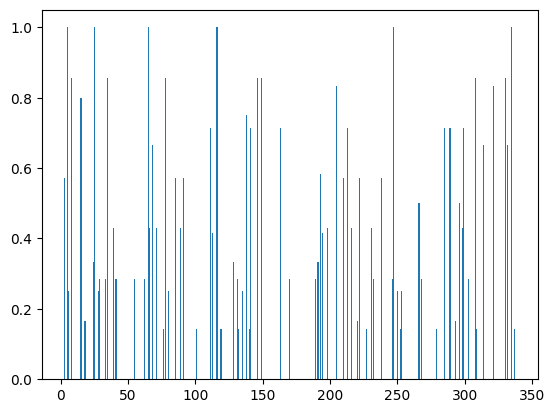

In [60]:



roc_auc= [0 for _ in range(342)]
fpr=[0 for _ in range(342)]
tpr=[0 for _ in range(342)]
      

for i in range(342): #over the species
      fpr[i], tpr[i], _ = roc_curve(target[:, i], pred[:, i].detach().numpy())
      roc_auc[i] = auc(fpr[i], tpr[i])



#plot
plt.bar(range(len(roc_auc)), roc_auc)
print(roc_auc)
print(np.mean(roc_auc))

In [ ]:
target[0].shape

torch.Size([1, 342])

In [57]:
target[2,1].detach().numpy()

array(0, dtype=int32)

In [56]:
roc_curve(target[2, 1].detach().numpy(), pred[2, 1].detach().numpy())

ValueError: unknown format is not supported

## 4. Model training

In [18]:
criterion = nn.BCELoss() 

from torch.optim import SGD

def setup_optimiser(model, learning_rate, weight_decay):
  return SGD(
    model.parameters(),
    learning_rate,
    weight_decay
  )

In [83]:
data.keys()

dict_keys(['survey_id', 'lon', 'lat', 'env_variables', 'landsat_timeseries', 'satellite_patch', 'species_labels'])

In [69]:
from tqdm.auto import trange      # pretty progress bar


def train_epoch(data_loader, model, optimiser, device):

  # set model to training mode. This is important because some layers behave differently during training and testing
  model.train(True)
  model.to(device)

  # stats
  loss_total = 0.0

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, sample in enumerate(data_loader): #our sample is not only data+ labels, but sample_id+ satelite patches +...+ labels
    data = {k: v for k, v in sample.items() if k != 'species_labels'}
    target = sample['species_labels'].float()

    # put data and target onto correct device
    data = {k: v.to(device) for k, v in data.items()}
    target = target.to(device)

    # reset gradients
    optimiser.zero_grad()

    # forward pass
    pred = model(data)

    # loss
    loss = criterion(pred, target)

    # backward pass
    loss.backward()

    # parameter update
    optimiser.step()

    # stats update
    loss_total += loss.item()

    # format progress bar
    pBar.set_description('Loss: {:.2f}'.format(
      loss_total/(idx+1),
     
    ))
    pBar.update(1)
  
  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)

  return model, loss_total

In [70]:
def validate_epoch(data_loader, model, device):       # note: no optimiser needed

  # set model to evaluation mode
  model.train(False)
  model.to(device)

  # stats
  loss_total = 0.0
  roc_auc= [0 for _ in range(342)]
  fpr=[0 for _ in range(342)]
  tpr=[0 for _ in range(342)]

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, sample in enumerate(data_loader): #our sample is not only data+ labels, but sample_id+ satelite patches +...+ labels
    data = {k: v for k, v in sample.items() if k != 'species_labels'}
    target = sample['species_labels'].float()
    with torch.no_grad():

      # put data and target onto correct device
      data = {k: v.to(device) for k, v in data.items()}
      target = target.to(device)

      # forward pass
      pred = model(data)

      # loss
      loss = criterion(pred, target)

      # stats update
      loss_total += loss.item()

      # format progress bar
      pBar.set_description('Loss: {:.2f}'.format(
        loss_total/(idx+1),
    
      ))
      pBar.update(1)

  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)

  # #auc
  # for i in range (342):
  #     fpr[i], tpr[i], _ = roc_curve(target[:, i], pred[:, i].detach().numpy())
  #     auc[i] = auc(fpr[i], tpr[i])
  # auc_mean=np.mean(auc)

  return loss_total

In [102]:
#load and save model

import glob

os.makedirs('cnn_states/multimodal_SDM', exist_ok=True)

def load_model(epoch='latest'):
  model = multimodal_SDM()
  modelStates = glob.glob('cnn_states/multimodal_SDM/*.pth')
  if len(modelStates) and (epoch == 'latest' or epoch > 0):
    modelStates = [int(m.replace('cnn_states/multimodal_SDM/','').replace('.pth', '')) for m in modelStates]
    if epoch == 'latest':
      epoch = max(modelStates)
    stateDict = torch.load(open(f'cnn_states/multimodal_SDM/{epoch}.pth', 'rb'), map_location='cpu')
    model.load_state_dict(stateDict)
  else:
    # fresh model
    epoch = 0
  return model, epoch


def save_model(model, epoch):
  torch.save(model.state_dict(), open(f'cnn_states/multimodal_SDM/{epoch}.pth', 'wb'))

In [73]:
# define hyperparameters
device = 'cpu'
start_epoch = 0        # set to 0 to start from scratch again or to 'latest' to continue training from saved checkpoint
batch_size = 8
learning_rate = 0.1
weight_decay = 0.001
num_epochs = 2


# initialise data loaders
dl_train = load_dataloader(batch_size, 'train')
dl_val = load_dataloader(batch_size, 'val')

# load model
model, epoch = load_model(epoch=start_epoch)
optim = setup_optimiser(model, learning_rate, weight_decay)

# do epochs
while epoch < num_epochs:

  # training
  model, loss_train = train_epoch(dl_train, model, optim, device)

  # validation
  loss_val = validate_epoch(dl_val, model, device)

  # print stats
  print('[Ep. {}/{}] Loss train: {:.2f}, val: {:.2f}'.format(
      epoch+1, num_epochs,
      loss_train, loss_val
  ))

  # save model
  epoch += 1
  save_model(model, epoch)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

[Ep. 1/2] Loss train: 0.16, val: 0.14


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

[Ep. 2/2] Loss train: 0.15, val: 0.14


ce que j'ai changé (Moea)
- argmax() au lieu de argmax(1)
- rajouté les .float() pour les data et labels
- diviser le dict issu de load_dataloader en data et label avec data qui contient plusieurs keys, donc ensuite move to device chacune des keys

## 5. Model evaluation

In [ ]:
from tqdm import tqdm
model=multimodal_SDM()
stateDict = torch.load(open(f'cnn_states/multimodal_SDM/50.pth', 'rb'), map_location='cpu') # achanger avec le bon nombre d'époquees
model.load_state_dict(stateDict)

dl_test = load_dataloader(1000,'test')

for idx, sample in tqdm(enumerate(dl_test)):
    with torch.no_grad():

      # put data onto correct device and separate target from data
      sample = {key: value.to(device) for key, value in sample.items()}
      target = sample['species_labels'].float()
      data = {key: value for key, value in sample.items() if key != 'species_labels'}
      pred_test=model(data)
print(pred_test)

#auc
fpr=[0 for _ in range(342)]
tpr=[0 for _ in range(342)]
roc_auc= [0 for _ in range(342)]
for i in range (342):
    fpr[i], tpr[i], _ = roc_curve(target[:, i], pred_test[:, i].detach().numpy())
    roc_auc[i] = auc(fpr[i], tpr[i])

1it [00:03,  3.25s/it]


tensor([[0.0160, 0.0329, 0.0140,  ..., 0.0062, 0.0037, 0.1515],
        [0.0218, 0.0231, 0.0129,  ..., 0.0495, 0.0111, 0.1217],
        [0.0171, 0.0269, 0.0106,  ..., 0.0031, 0.0021, 0.1573],
        ...,
        [0.0489, 0.0318, 0.0002,  ..., 0.0035, 0.0008, 0.0115],
        [0.0054, 0.0015, 0.0011,  ..., 0.0463, 0.0371, 0.0216],
        [0.0224, 0.0238, 0.0077,  ..., 0.0018, 0.0011, 0.1189]])


[0.676085274420342, 0.6188639035861259, 0.8189898989898989, 0.6291664812424904, 0.4311021414956834, 0.48074170245347714, 0.6832057449538849, 0.46909221470887436, 0.6919264527845037, 0.7862989124341293, 0.7008027433559348, 0.4653263157894737, 0.5497501469723692, 0.5617244232006618, 0.697993997788659, 0.6920426666666667, 0.7526079397276152, 0.7181174089068826, 0.6850126094533018, 0.6056338028169014, 0.5457113880034773, 0.5987861570247934, 0.6984919604514132, 0.6682474226804125, 0.5473953673327369, 0.588100947813178, 0.6330773688785859, 0.5452577319587629, 0.6243789473684211, 0.5919845485272814, 0.6853750797557195, 0.8384042650978949, 0.5587170151123639, 0.7398876404494381, 0.7089579659024103, 0.7554053329041257, 0.619770580296896, 0.6609980326876513, 0.7937310414560161, 0.37003767024051, 0.5518264507028552, 0.7423245614035088, 0.6211157894736843, 0.7194752774974773, 0.46221416620189626, 0.7327931301652892, 0.8503711201079622, 0.698265306122449, 0.6167355371900827, 0.7712387577951176, 0.7

AttributeError: module 'numpy' has no attribute 'stats'

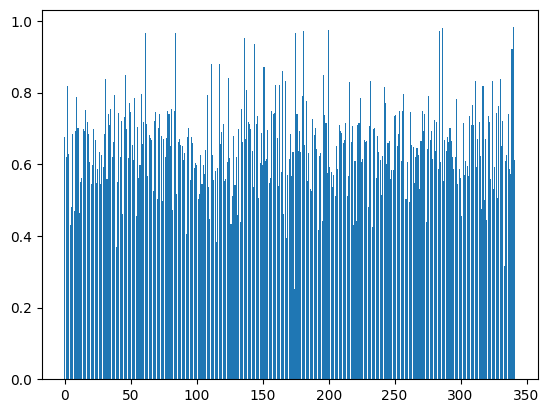

In [118]:
from sklearn.metrics import roc_curve, auc

for i in range (342):
    fpr[i], tpr[i], _ = roc_curve(target[:, i], pred_test[:, i].detach().numpy())
    roc_auc[i] = auc(fpr[i], tpr[i])
auc_mean=np.mean(roc_auc)

plt.bar(range(len(roc_auc)), roc_auc)
print(roc_auc)
print(np.stats(roc_auc))

{'whiskers': [<matplotlib.lines.Line2D at 0x1de6530f110>,
 'caps': [<matplotlib.lines.Line2D at 0x1de6530f390>,
 'boxes': [<matplotlib.lines.Line2D at 0x1de6530efd0>],
 'medians': [<matplotlib.lines.Line2D at 0x1de6530f610>],
 'fliers': [<matplotlib.lines.Line2D at 0x1de6530f750>],
 'means': []}

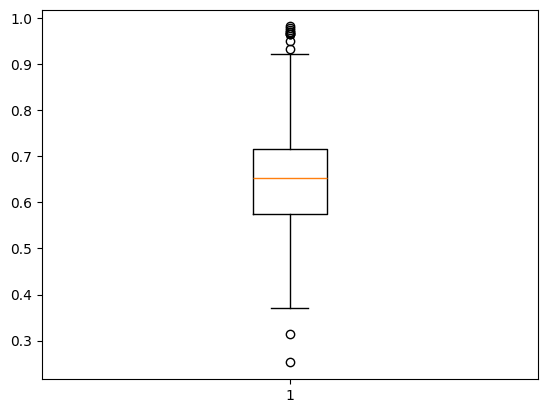

In [119]:
plt.boxplot(roc_auc)

In [5]:
import numpy as np
(np.array([0.2, 0.5, 0.7, 0.1, 0.3]) > 0.5).astype(int)

array([0, 0, 1, 0, 0])

In [ ]:
#F1 score with a treshold of 0.5
# we can select the best treshold for each species according to the F1 score
from sklearn.metrics import f1_score
f1_scores = [0 for _ in range(342)]
for i in range(342): # for each species
    f1 = f1_score(target[:, i].cpu(), (pred_test[:, i].detach().numpy().cpu() > 0.5).astype(int)) #0.5 treshold
    f1_scores[i] = f1
print(f1_scores)
plt.bar(range(len(f1_scores)), f1_scores)

# micro f1 score
f1_micro = f1_score(target.cpu(), (pred_test.detach().numpy().cpu() > 0.5).astype(int), average='micro')
print(f1_micro)